**Hint:** To help with the high compute demand of DAS models, SeisBench integrates GPU support. For this tutorial, we strongly recommend to select a Colab runtime with GPU support. To enable GPU support, select *Runtime -> Change runtime type* from the menu.

![image](https://raw.githubusercontent.com/seisbench/seisbench/main/docs/_static/seisbench_logo_subtitle_outlined.svg)

This code installs the necessary dependencies for the tutorial. As not all features have been released in a named version yet, we need to install SeisBench from the git repository.

In [ ]:
pip install "seisbench[das] @ git+https://github.com/seisbench/seisbench"

# DAS phase picking with SeisBench

First, we import the necessary libraries:
- From SeisBench, we import `seisbench.models`, providing access to the different classical and DAS models.
- `xdas` provides IO and processing functionality for DAS data. It comes with support for data from all common interogators and supports larger-than-memory processing. This tutorial explains a few features of xdas, but should not be treated as a comprehensive guide.
- `matplotlib` and `pandas` are used for some data visualization and data handling.

In [1]:
import seisbench.models as sbm
import xdas
import matplotlib.pyplot as plt
import pandas as pd

## Loading and inspecting the data

In this tutorial, we use an example trace recorded offshore Chile. The file is stored on the SeisBench repository. Download the file with the command below.

In [8]:
!wget https://hifis-storage.desy.de/Helmholtz/HelmholtzAI/SeisBench/auxiliary/chile_das_example.netcdf

--2026-04-14 15:07:30--  http://hifis-storage.desy.de/Helmholtz/HelmholtzAI/SeisBench/auxiliary/chile_das_example.netcdf
Resolving hifis-storage.desy.de (hifis-storage.desy.de)... 131.169.168.93
Connecting to hifis-storage.desy.de (hifis-storage.desy.de)|131.169.168.93|:80... ^C


The SeisBench DAS interface is built on top of [xdas](https://xdas.readthedocs.io/en/latest/), a python framework for DAS processing. In particular, IO is performed through xdas, making SeisBench independent of the underlying data format. The example file is in NetCDF format, written by xdas. However, xdas can also read raw records from diverse 

Let's load the file with the command below and print the output. Note that the data is marked as a "VirtualSource". xdas only scanned the metadata, but didn't load the whole data into memory. This will become relevant later for larger-than-memory processing.

In [4]:
data = xdas.open_dataarray("chile_das_example.netcdf")
print(data)

<xdas.DataArray (time: 22500, distance: 36718)>
VirtualSource: 3.1GB (float32)
Coordinates:
  * time (time): 2021-11-28T08:49:07.000 to 2021-11-28T08:52:51.990
  * distance (distance): 0.000 to 367170.000


To get a quick impression of the data, we visualize a subset. We show all samples, but only every 50th channel. Note how we can select samples and channels with simple index notation. xdas also supports more advanced indexing that isn't discussed in this tutorial.

Looking at the plot, you can see that the record contains one earthquake with P and S arrival fronts around 08:50:00.

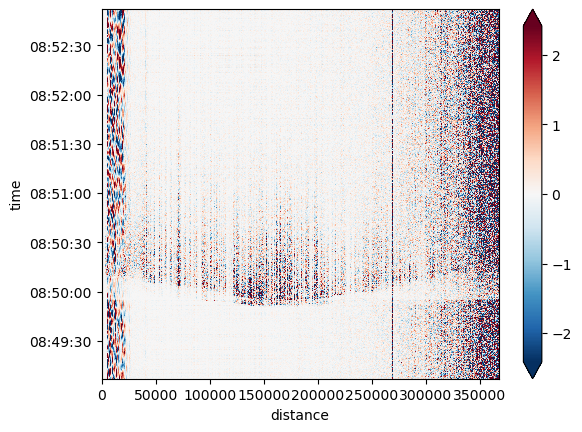

In [5]:
data[
    :,  # All samples
    ::50  # Only every 50th channel
].plot(robust=True)

For the purpose of this tutorial, processing the whole data would take too long. Instead, let's focus on a subset of channels and samples where we have both P and S arrivals.

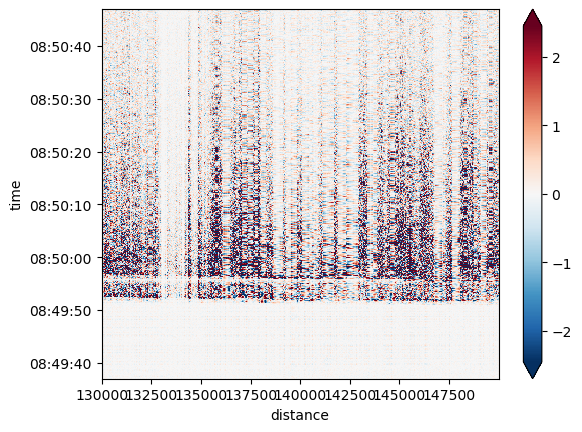

In [6]:
data_selected = data[
    3000:10000,  # Samples
    13000:15000  # Channels
]
data_selected.plot(robust=True)

## Wrapping 3C models

As a first approach, we use a model trained on 3C data from classical seismometers. While these models are not optimal for DAS data, they are lightweight and readily available. For this example, we use a PhaseNet model trained on the DiTing dataset. PhaseNet is one of the most commonly used phase pickers for classical seismometers. DiTing consists of a large number of seismic records from China. The model weights are loaded automatically from the SeisBench server and cached for future use.

In the next step, we wrap the 3C model for DAS data. The wrapper ensures that the DAS data is efficiently chunked up, processed and reassembled by the 3D model.

*Note:* You might have spotted the `component_strategy="clone"` argument. This means that SeisBench will show each DAS component three times before feeding it to PhaseNet. This is necessary, as PhaseNet expects 3-component input data. An alternative strategy is `"pad"`, where SeisBench provides the DAS signal as the first channel and sets the other channels to zero.

In [7]:
base_model = sbm.PhaseNet.from_pretrained("diting")
model = sbm.DASWaveformModelWrapper(base_model, component_strategy="clone")

DAS data processing is computationally heavy. To accelerate this process, GPUs can be used. SeisBench provides automatic GPU support, simply by moving the model to the right device. If this command does not show a GPU, it might be that you did not select a GPU runtime (see hint at the top of the notebook).

*Note:* SeisBench does not only support GPUs, but also Apple Silicon accelerators and Intel XPUs. The `to_preferred_device` method will automatically identify, which of these are available.

In [8]:
model.to_preferred_device(verbose=True)

Model device: xpu:0


Now to the actual processing. Deep learning models can not process the whole input patch at once and are often restricted to specific input shapes. SeisBench is aware of these shapes and will automatically chunk the input data into the right chunks before passing them to the model. For speeding up the processing, chunks are batched. Larger batch sizes use more (GPU-)memory, but typically speed up processing.

The outputs of DAS models are large, for example, the P and S probability maps both have the same size as the input. Keeping the whole output in memory before doing furhter processing would be prohibitive for all but the smallest inputs. SeisBench solves this with **callbacks**. A callback is a function applied to each chunk of the output data. For example, a callback can extract all picks or write the output to disk. Afterwards, we can safely discard the predictions for this chunk to save memory. We'll encounter a few callbacks below.

The most simple callback is shown below. It collects all outputs in the main memory. This is only feasible for small inputs, but great for visualization.

In [9]:
callback = sbm.InMemoryCollectionCallback()

To apply the model, we use the `annotate` or `annotate_async` function and pass in our data and the callback.

**Technical detail:** We use the async-await syntax here. This is a quirk of Jupyter notebooks. Jupyter notebooks runs a so-called asyncio event loop that we use. Outside the notebook, you would simply call `model.annotate` and drop the `await`. In principle, this works also in Jupyter notebooks but it can lead to instabilities.

In [10]:
await model.annotate_async(data_selected, callback, batch_size=2)

100%|█████████████████████████████████████████████| 8/8 [00:03<00:00,  2.41it/s]


After running the model, we can access the outputs, i.e., the probability maps for P and S waves. These are stored as xdas arrays in the callback. In contrast to the original data array, they are not virtual, but have their data in memory.

In [11]:
callback.get_results_dict()["P"]

<xdas.DataArray (time: 6500, distance: 2000)>
[[9.263986e-06 9.190129e-06 6.317916e-06 ... 2.362191e-06 1.078454e-05
  8.248430e-06]
 [8.911647e-06 8.873557e-06 6.620186e-06 ... 2.845945e-06 1.094848e-05
  9.016931e-06]
 [8.711657e-06 8.216183e-06 6.269176e-06 ... 2.773658e-06 9.988551e-06
  9.136092e-06]
 ...
 [2.215581e-05 5.201356e-05 4.755571e-05 ... 1.043804e-04 3.619201e-05
  2.900195e-05]
 [2.335062e-05 5.448225e-05 4.969470e-05 ... 9.002731e-05 3.215376e-05
  2.423495e-05]
 [2.191075e-05 5.692445e-05 4.835394e-05 ... 9.227802e-05 3.134141e-05
  2.472579e-05]]
Coordinates:
  * time (time): 2021-11-28T08:49:39.500 to 2021-11-28T08:50:44.490
  * distance (distance): 130000.000 to 149990.000

Let's visualize the probability maps. The P and S probability curves are clearly visible, even though they seem slightly rugged.

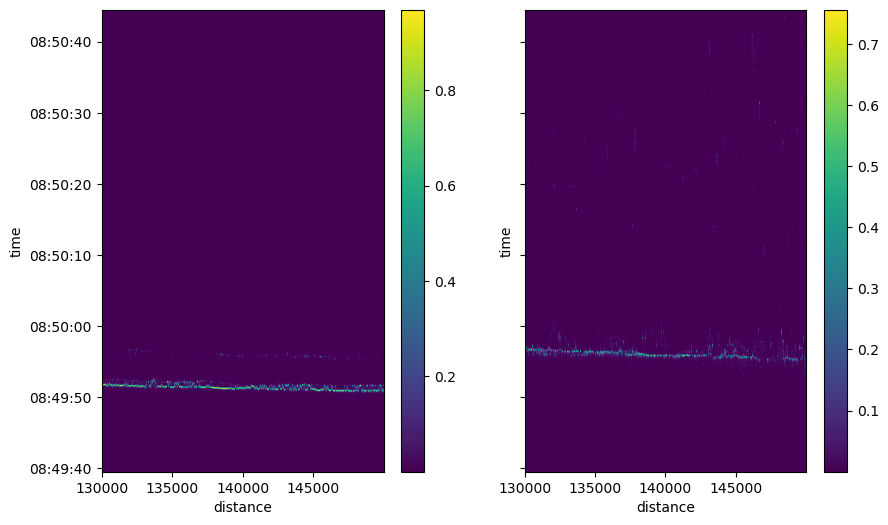

In [8]:
fig = plt.figure(figsize=(10, 6))
axs = fig.subplots(1, 2, sharex=True, sharey=True)
callback.get_results_dict()["P"].plot(ax=axs[0])
callback.get_results_dict()["S"].plot(ax=axs[1])

In most cases, we won't need the whole probability curve but are just interested in the picks. To this end, SeisBench offers the `DASPickingCallback`. We could use it directly, as for the example above. However, SeisBench DAS models also come with default callbacks that match their functionality. For example, picking models use the picking callback as default. We can use it through the `classify` (or `classify_async`) function.

In [12]:
output = await model.classify_async(data_selected, thresholds={"P": 0.3, "S": 0.3})

100%|█████████████████████████████████████████████| 8/8 [00:02<00:00,  3.22it/s]


The output consists of a list of P pick objects and a list of S pick objects.

In [15]:
output

namespace(creator='DASWaveformModelWrapper',
          P=[DASPick(time=np.datetime64('2021-11-28T08:49:51.320000000'), confidence=np.float64(0.6711539030075073), channel=np.float64(139760.0), phase='P', start_time=None, end_time=None),
             DASPick(time=np.datetime64('2021-11-28T08:49:52.380000000'), confidence=np.float64(0.41784271597862244), channel=np.float64(130000.0), phase='P', start_time=None, end_time=None),
             DASPick(time=np.datetime64('2021-11-28T08:49:51.320000000'), confidence=np.float64(0.7261223793029785), channel=np.float64(139780.0), phase='P', start_time=None, end_time=None),
             DASPick(time=np.datetime64('2021-11-28T08:49:51.300000000'), confidence=np.float64(0.7124660015106201), channel=np.float64(139790.0), phase='P', start_time=None, end_time=None),
             DASPick(time=np.datetime64('2021-11-28T08:49:51.320000000'), confidence=np.float64(0.595255970954895), channel=np.float64(139800.0), phase='P', start_time=None, end_time=None),


To use the picks, it's convenient to convert them into a pandas array. This also allows to easily store them, for example, as csv of parquet files.

In [10]:
pd.DataFrame(output.P).sort_values("channel")

,time,confidence,channel,phase,start_time,end_time
1,2021-11-28 08:49:52.380,0.417843,130000.0,P,None,None
6,2021-11-28 08:49:51.730,0.798240,130060.0,P,None,None
8,2021-11-28 08:49:52.430,0.427913,130070.0,P,None,None
10,2021-11-28 08:49:52.490,0.406435,130080.0,P,None,None
12,2021-11-28 08:49:51.790,0.803780,130100.0,P,None,None
...,...,...,...,...,...,...
1088,2021-11-28 08:49:50.940,0.659391,149530.0,P,None,None
1091,2021-11-28 08:49:50.920,0.673273,149560.0,P,None,None
1112,2021-11-28 08:49:51.670,0.639493,149750.0,P,None,None
1122,2021-11-28 08:49:50.900,0.621116,149850.0,P,None,None


In [11]:
pd.DataFrame(output.S).sort_values("channel")

,time,confidence,channel,phase,start_time,end_time
0,2021-11-28 08:49:56.490,0.384215,130000.0,S,None,None
1,2021-11-28 08:49:56.810,0.447138,130080.0,S,None,None
2,2021-11-28 08:49:56.810,0.385676,130090.0,S,None,None
4,2021-11-28 08:49:56.900,0.393720,130100.0,S,None,None
734,2021-11-28 08:49:56.530,0.445534,130130.0,S,None,None
...,...,...,...,...,...,...
733,2021-11-28 08:49:57.800,0.417553,149740.0,S,None,None
570,2021-11-28 08:49:58.360,0.375113,149750.0,S,None,None
572,2021-11-28 08:49:58.330,0.504762,149760.0,S,None,None
574,2021-11-28 08:49:58.320,0.309330,149770.0,S,None,None


To validate the quality of our picks visually, let's plot them on the original data. Overall, we can see that the picker did a good job and the P and S picks match the P and S wavefronts visually. However, upon closer inspection you might find a few quirks:
- Not all channels have picks and gaps in the pick fronts appear frequently.
- There are a a few spurious picks. They become a little more obvious when you increase the size of the pick markers.
- A number of S arrivals have been labeled P. This becomes obvious when disabling the plotting of S picks. Currently they are pretty much hidden underneath.
- If you look closely, you might see that there are two different wavefronts over which the P picks are distributed. One is the direct P arrival, the other is a Ps sediment conversion. There's a lot more detail on the phenomenon in [this article](https://doi.org/10.1029/2024JB029054).

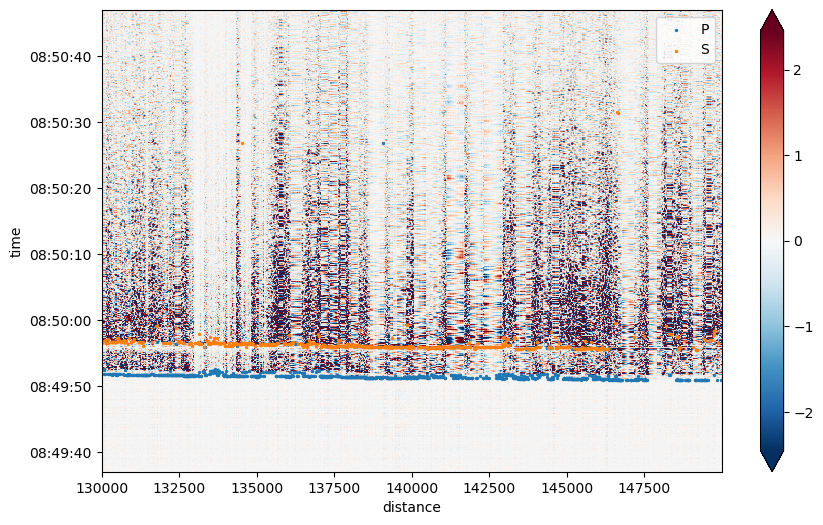

In [12]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
data_selected.plot(robust=True, ax=ax)

p_picks = pd.DataFrame(output.P)
s_picks = pd.DataFrame(output.S)
ax.scatter(p_picks["channel"], p_picks["time"], s=2, label="P")
ax.scatter(s_picks["channel"], s_picks["time"], s=2, label="S")
ax.legend(loc="upper right")

## DeepSubDAS - A DAS-native model

While the above experiment shows that 3C models can be applied to DAS, they are clearly not optimal. They miss out on the spatial coherence of the signal, a big strength of DAS data. To this end, SeisBench offers DAS-native models. Here, we will use DeepSubDAS. As before, we start with loading the model. The pretrained weights are downloaded from the SeisBench server.

In [2]:
model = sbm.DeepSubDAS.from_pretrained("original")

As before, it is strongly recommended to move the model to a GPU if available.

In [3]:
model.to_preferred_device(verbose=True)

Model device: xpu:0


The callback system works identical for DAS-native models as for the wrapper. Again, we use the in-memory callback.

In [15]:
callback = sbm.InMemoryCollectionCallback()
await model.annotate_async(data_selected, callback, batch_size=2)

100%|█████████████████████████████████████████████| 3/3 [00:27<00:00,  9.05s/it]


Visualizing the outputs, it is obvious that the picks are spatially much more coherent than for the wrapped 3C model. We also get higher model confidence values.

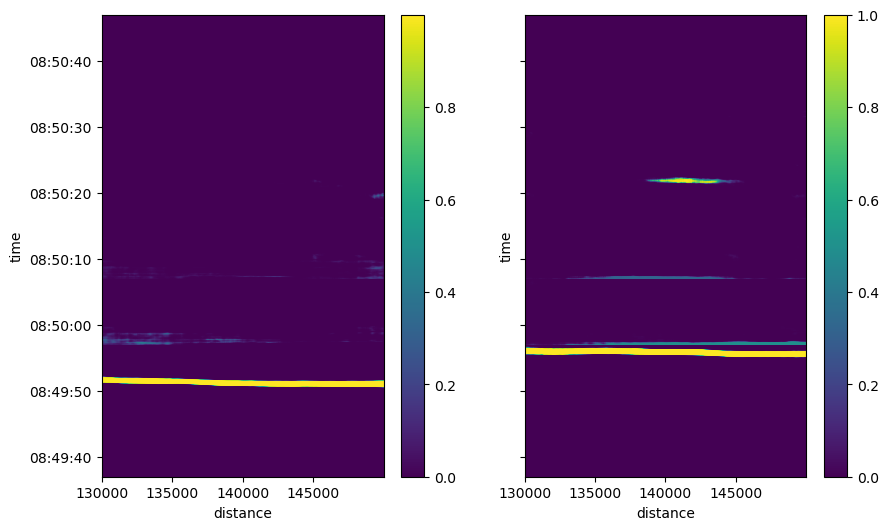

In [16]:
fig = plt.figure(figsize=(10, 6))
axs = fig.subplots(1, 2, sharex=True, sharey=True)
callback.get_results_dict()["P"].plot(ax=axs[0])
callback.get_results_dict()["S"].plot(ax=axs[1])

Let's have a look at the picks. Given the high confidence we've observed, we use a high picking threshold to avoid false positive detection.

In [21]:
output = await model.classify_async(data_selected, thresholds={"P": 0.9, "S": 0.9})

100%|█████████████████████████████████████████████| 3/3 [00:25<00:00,  8.64s/it]


In [22]:
pd.DataFrame(output.P).sort_values("channel")

,time,confidence,channel,phase,start_time,end_time
0,2021-11-28 08:49:51.750,0.999847,130000.0,P,None,None
1,2021-11-28 08:49:51.750,0.999847,130010.0,P,None,None
2,2021-11-28 08:49:51.750,0.999847,130020.0,P,None,None
3,2021-11-28 08:49:51.750,0.999847,130030.0,P,None,None
4,2021-11-28 08:49:51.750,0.999860,130040.0,P,None,None
...,...,...,...,...,...,...
1995,2021-11-28 08:49:51.110,0.999925,149950.0,P,None,None
1996,2021-11-28 08:49:51.110,0.999915,149960.0,P,None,None
1997,2021-11-28 08:49:51.110,0.999915,149970.0,P,None,None
1998,2021-11-28 08:49:51.110,0.999915,149980.0,P,None,None


In [23]:
pd.DataFrame(output.S).sort_values("channel")

,time,confidence,channel,phase,start_time,end_time
0,2021-11-28 08:49:56.150,0.999770,130000.0,S,None,None
1,2021-11-28 08:49:56.150,0.999770,130010.0,S,None,None
2,2021-11-28 08:49:56.150,0.999770,130020.0,S,None,None
3,2021-11-28 08:49:56.150,0.999770,130030.0,S,None,None
4,2021-11-28 08:49:56.150,0.999788,130040.0,S,None,None
...,...,...,...,...,...,...
2418,2021-11-28 08:49:55.670,0.999712,149950.0,S,None,None
2419,2021-11-28 08:49:55.670,0.999670,149960.0,S,None,None
2420,2021-11-28 08:49:55.670,0.999670,149970.0,S,None,None
2421,2021-11-28 08:49:55.670,0.999670,149980.0,S,None,None


Looking at the picks, we can confirm that the pick front is now much more consistent. In fact, it even correctly picked the direct P arrival throughout instead of the Ps conversion. You might notice that there's still a spurious S arrival, this time spanning multiple channels.

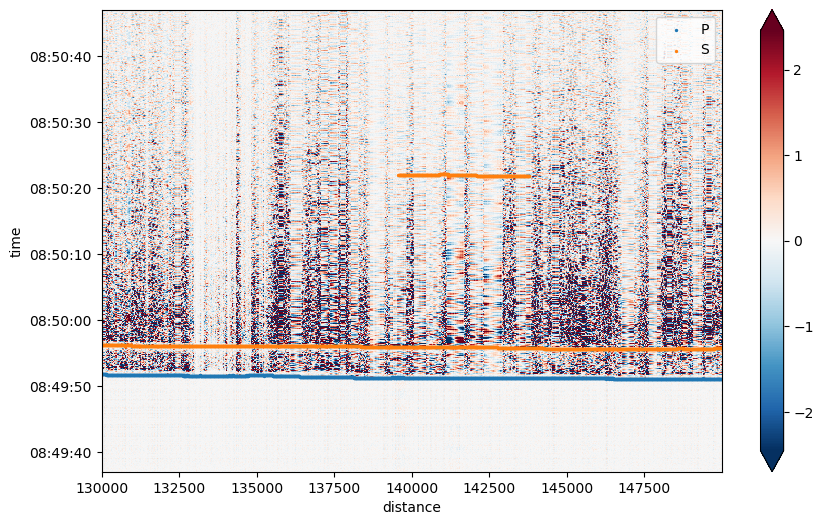

In [24]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
data_selected.plot(robust=True, ax=ax)

p_picks = pd.DataFrame(output.P)
s_picks = pd.DataFrame(output.S)
ax.scatter(p_picks["channel"], p_picks["time"], s=2, label="P")
ax.scatter(s_picks["channel"], s_picks["time"], s=2, label="S")
ax.legend(loc="upper right")

# Larger-than-memory processing

DAS data can be very large, often substantially exceeding the available main memory. The SeisBench implementation is designed to handle such data. First, by using xdas, SeisBench can use virtual input data. The data is only loaded for the chunks currently processed and evicted from memory right after, keeping the memory consumption independent of the total size of the dataset. Second, the callback architecture provides a way of handling the output without keeping it in memory. Below, we show two examples of this, using the whole input data. Note that depending on your choice of model and the CPU/GPU, running these commands might take a while.

In [16]:
model_3c = True  # Select which model to use

if model_3c:
    base_model = sbm.PhaseNet.from_pretrained("diting")
    model = sbm.DASWaveformModelWrapper(base_model, component_strategy="clone")
else:
    model = sbm.DeepSubDAS.from_pretrained("original")

model.to_preferred_device(verbose=True)

Model device: xpu:0


Reload the data, this time without subselection.

In [17]:
data = xdas.open_dataarray("chile_das_example.netcdf")
print(data)

<xdas.DataArray (time: 22500, distance: 36718)>
VirtualSource: 3.1GB (float32)
Coordinates:
  * time (time): 2021-11-28T08:49:07.000 to 2021-11-28T08:52:51.990
  * distance (distance): 0.000 to 367170.000


Phase picking with the classify method. The picks will be collected in memory while the raw predictions will be discarded on-the-fly.

In [18]:
output = await model.classify_async(data, thresholds={"P": 0.2, "S": 0.2}, batch_size=2)

100%|█████████████████████████████████████████| 504/504 [02:23<00:00,  3.51it/s]


Lastly, we use the `WriterCallback` to write the full probability functions to disk.

In [19]:
callback = sbm.WriterCallback("das_characteristic_functions")
await model.annotate_async(data, callback, batch_size=2)

100%|█████████████████████████████████████████| 504/504 [02:26<00:00,  3.44it/s]


As a last step, let's inspect the outputs. We only look at the P probability map, but the concept works the same for the S wave. Notice how the output is again an xdas array and can be used as a virtual array.

*Note:* Plotting every 50th channel is not quite optimal here, given the strong variability between adjacent channels. A better version would be some kind of anti-aliasing approach, but for simplicity, we omit this here.

<xdas.DataArray (time: 22000, distance: 36718)>
VirtualStack: 6.0GB (float64)
Coordinates:
  * time (time): 2021-11-28T08:49:09.500 to 2021-11-28T08:52:49.490
  * distance (distance): 0.000 to 367170.000


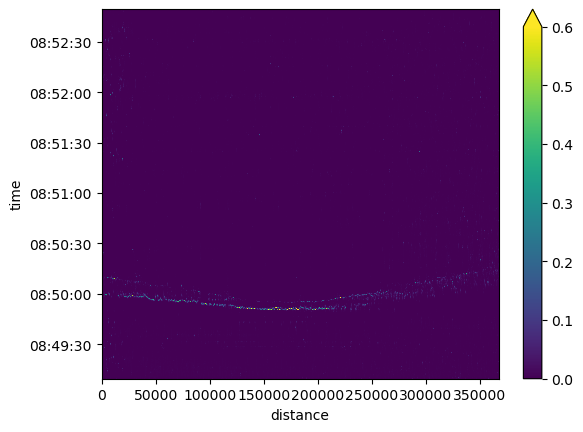

In [23]:
p_map = xdas.open_mfdataarray("das_characteristic_functions/P/*")
print(p_map)

p_map[
    :,  # All samples
    ::50  # Only every 50th channel
].plot(vmin=0, vmax=0.6)

This tutorial showed how to use the SeisBench DAS interface for processing DAS records. It introduced both wrapped models for classical data and DAS-native models. The implementation is based on virtual input data and callbacks, allowing to process larger-than-memory datasets.